# 🛣️ Khám phá các loại nhãn trong RDD-2022
Notebook này hiển thị danh sách các nhãn hư hại mặt đường có trong bộ dữ liệu RDD-2022 và vẽ ví dụ minh họa cho từng nhãn.


In [1]:
import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

PROJECT_ROOT = Path(r'd:\Research\Yolo_Pothole_detection\Pothole_Detection')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
RDD_DIR = RAW_DATA_DIR / 'rdd2022' / 'RDD_SPLIT'

RDD_CLASSES = {
    0: 'Longitudinal Crack',   # Vết nứt dọc
    1: 'Transverse Crack',     # Vết nứt ngang
    2: 'Alligator Crack',      # Nứt lưới/mai rùa
    3: 'Other Corruption',     # Hư hại khác
    4: 'Pothole'               # Ổ gà
}

print(f"📁 RDD_DIR: {RDD_DIR}")


📁 RDD_DIR: d:\Research\Yolo_Pothole_detection\Pothole_Detection\data\raw\rdd2022\RDD_SPLIT


In [2]:
def parse_yolo_label(label_path):
    boxes = []
    if label_path.exists():
            with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    boxes.append({
                        'class_id': int(parts[0]),
                        'x_center': float(parts[1]),
                        'y_center': float(parts[2]),
                        'width': float(parts[3]),
                        'height': float(parts[4])
                    })
    return boxes

def draw_yolo_boxes(img_path, label_path, class_names, ax):
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    boxes = parse_yolo_label(label_path)
    
    # Bảng màu đại diện cho 5 lớp
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#BB8FCE']
    
    for box in boxes:
        cls_id = box['class_id']
        color = colors[cls_id % len(colors)]
        
        # Chuyển đổi tọa độ YOLO -> Pixel
        x_center = box['x_center'] * w
        y_center = box['y_center'] * h
        bw = box['width'] * w
        bh = box['height'] * h
        x1 = x_center - bw / 2
        y1 = y_center - bh / 2
        
        # Vẽ khung
        rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # Thêm nhãn chữ
        label = class_names.get(cls_id, f'Class {cls_id}')
        ax.text(x1, y1 - 5, label, color='white', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85))
    ax.set_axis_off()


C:\Users\Admin\AppData\Local\Temp\ipykernel_28912\3492281098.py:49: UserWarning: Glyph 128739 (\N{MOTORWAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


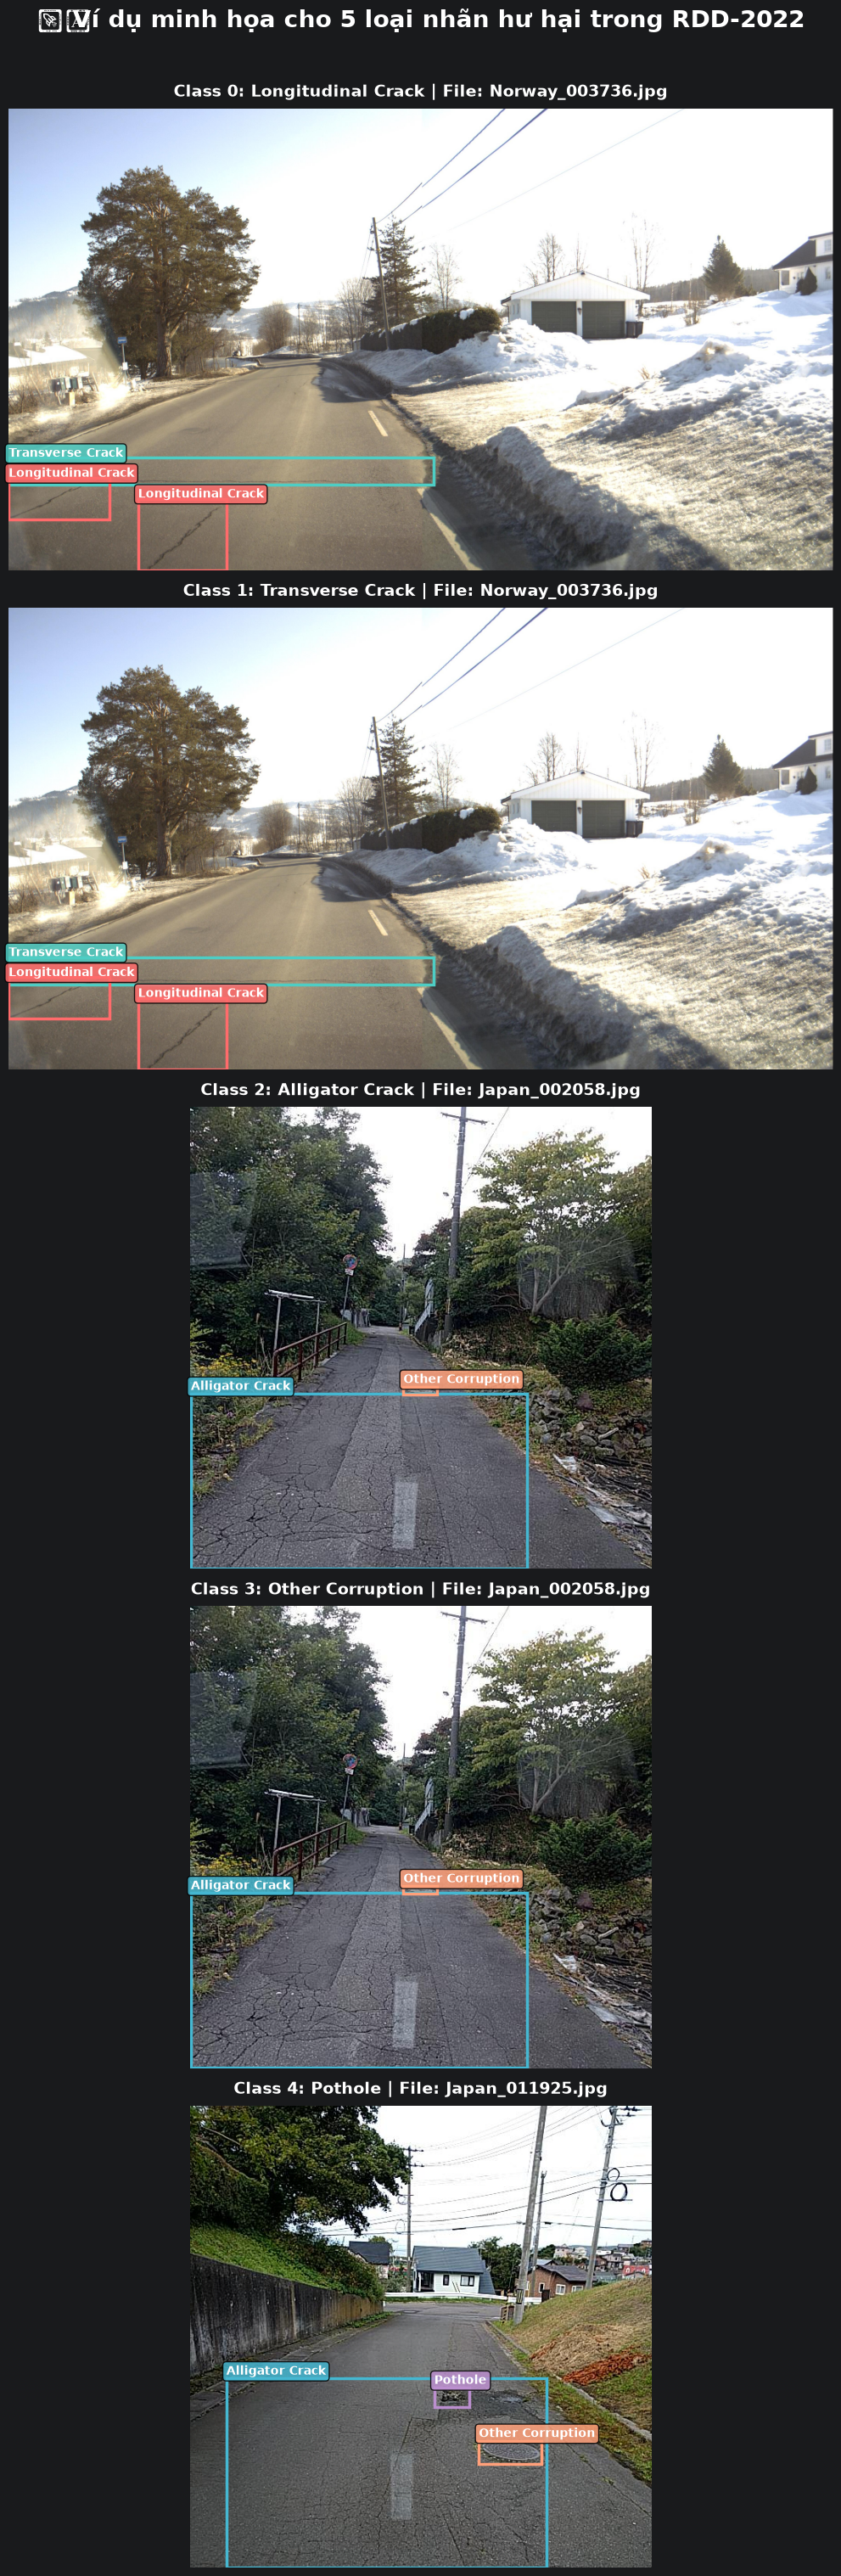

In [5]:
# Tìm 1 ví dụ ngẫu nhiên cho mỗi lớp
examples = {}  # class_id -> (img_path, lbl_path)

train_labels = list((RDD_DIR / 'train' / 'labels').glob('*.txt'))
random.seed(42)  # Cố định seed để kết quả ổn định
random.shuffle(train_labels)

for lbl_path in train_labels:
    if len(examples) == len(RDD_CLASSES):
        break
        
    boxes = parse_yolo_label(lbl_path)
    for box in boxes:
        cls_id = box['class_id']
        if cls_id not in examples:
            # Tìm ảnh tương ứng
            img_dir = RDD_DIR / 'train' / 'images'
            img_path = None
            for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG', '.JPEG']:
                candidate = img_dir / f"{lbl_path.stem}{ext}"
                if candidate.exists():
                    img_path = candidate
                    break
            
            if img_path:
                examples[cls_id] = (img_path, lbl_path)

# Vẽ biểu đồ 5 cột
fig, axes = plt.subplots(5, 1, figsize=(12, 30))

# Điều chỉnh y=1.01 để tiêu đề không bị dính quá sát vào ảnh trên cùng
fig.suptitle('🛣️ Ví dụ minh họa cho 5 loại nhãn hư hại trong RDD-2022',
             fontsize=20, fontweight='bold', y=1.01)

for cls_id in sorted(RDD_CLASSES.keys()):
    ax = axes[cls_id]
    if cls_id in examples:
        img_path, lbl_path = examples[cls_id]
        draw_yolo_boxes(img_path, lbl_path, RDD_CLASSES, ax)
        # Tăng kích thước font chữ của title từng ảnh cho dễ nhìn
        ax.set_title(f"Class {cls_id}: {RDD_CLASSES[cls_id]} | File: {img_path.name}",
                     fontsize=14, fontweight='bold', pad=10)
    else:
        ax.text(0.5, 0.5, f"Không tìm thấy ví dụ\ncho Class {cls_id}",
                ha='center', va='center', fontsize=14)
        ax.set_axis_off()

# Hỗ trợ tự động căn lề các khung hình để không bị lẹm chữ
plt.tight_layout()
plt.show()
